# Notebook 05e — Popularity Penalty: Threshold vs. Continuous

`05d` shipped the **threshold** version (only obscure songs get penalized). This
notebook shows the math for the alternative we didn't ship -- a **continuous**
penalty that nudges every song by its popularity, not just the obscure ones -- so
the tradeoff is documented, not just decided.


In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROCESSED = r"C:\Users\ryanm\Documents\coding_projects\restaurant_recommendation\data\processed"
songs = pd.read_csv(os.path.join(PROCESSED, "song_pca_new.csv"))
print(f"Songs: {songs.shape}")


Songs: (81198, 11)


## The two formulas

**Threshold** (shipped): below a popularity floor, penalty ramps up smoothly as
popularity approaches 0. At or above the floor, no penalty at all -- most songs are
untouched.

$$\text{penalty}_{\text{threshold}}(p) = \begin{cases} 1 & p \ge \text{floor} \\ \sqrt{\dfrac{\text{floor}}{p+1}} & p < \text{floor} \end{cases}$$

**Continuous** (alternative): every song gets a penalty based on how far its
popularity is from the maximum (100) -- even a fairly popular song ranks slightly
worse than a more popular one, not just a binary "obscure or not." (`+1` inside both
logs is just to avoid dividing by zero at `popularity == 0`.)

$$\text{penalty}_{\text{continuous}}(p) = \dfrac{\ln(1 + 100)}{\ln(1 + p + 1)}$$

Both equal exactly 1.0 at their respective "no penalty" point (threshold: at the
floor; continuous: only at popularity = 100, the maximum possible).


In [2]:
POPULARITY_FLOOR = 10
MAX_POPULARITY = 100

def penalty_threshold(popularity, floor=POPULARITY_FLOOR):
    pop = np.asarray(popularity, dtype=float)
    penalty = np.ones_like(pop)
    obscure = pop < floor
    penalty[obscure] = np.sqrt(floor / (pop[obscure] + 1))
    return penalty

def penalty_continuous(popularity, max_pop=MAX_POPULARITY):
    pop = np.asarray(popularity, dtype=float)
    return np.log1p(max_pop) / np.log1p(pop + 1)


## Side by side, at a few popularity values


In [3]:
sample_pops = [0, 5, 9, 10, 20, 30, 50, 70, 100]
comparison = pd.DataFrame({
    "popularity": sample_pops,
    "threshold_penalty": penalty_threshold(np.array(sample_pops)).round(3),
    "continuous_penalty": penalty_continuous(np.array(sample_pops)).round(3),
})
comparison


,popularity,threshold_penalty,continuous_penalty
0,0,3.162,6.658
1,5,1.291,2.372
2,9,1.000,1.925
3,10,1.000,1.857
4,20,1.000,1.493
5,30,1.000,1.332
6,50,1.000,1.168
7,70,1.000,1.079
8,100,1.000,0.998


## The curves

Threshold is flat at 1.0 above the floor, then rises sharply for the last few
obscure songs. Continuous is a smooth downward slope across the *entire* range --
it never fully "lets go" of a song, even a popular one, until popularity hits 100.


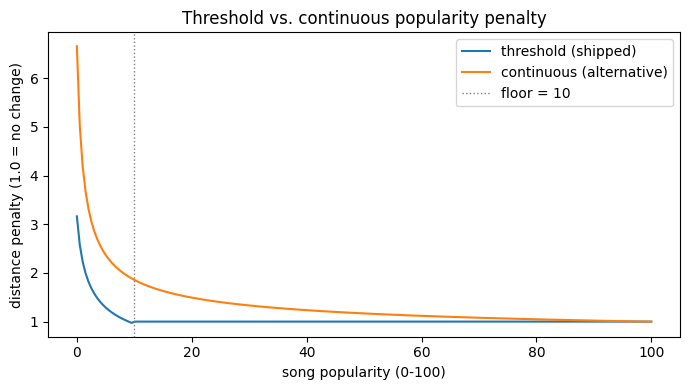

In [4]:
pop_range = np.linspace(0, 100, 200)

plt.figure(figsize=(7, 4))
plt.plot(pop_range, penalty_threshold(pop_range), label="threshold (shipped)")
plt.plot(pop_range, penalty_continuous(pop_range), label="continuous (alternative)")
plt.axvline(POPULARITY_FLOOR, color="gray", linestyle=":", linewidth=1, label=f"floor = {POPULARITY_FLOOR}")
plt.xlabel("song popularity (0-100)")
plt.ylabel("distance penalty (1.0 = no change)")
plt.title("Threshold vs. continuous popularity penalty")
plt.legend()
plt.tight_layout()
plt.show()


## How many songs does each one actually touch?


In [5]:
pops = songs["popularity"].values
th = penalty_threshold(pops)
co = penalty_continuous(pops)

print(f"Threshold:  {np.sum(th > 1.0):,} / {len(pops):,} songs penalized at all "
      f"({np.mean(th > 1.0):.1%})")
print(f"Continuous: {np.sum(co > 1.0):,} / {len(pops):,} songs penalized at all "
      f"({np.mean(co > 1.0):.1%})")
print()
print("Continuous touches every song except the single most popular one(s) -- "
      "threshold only touches the bottom slice.")


Threshold:  8,520 / 81,198 songs penalized at all (10.5%)
Continuous: 81,196 / 81,198 songs penalized at all (100.0%)

Continuous touches every song except the single most popular one(s) -- threshold only touches the bottom slice.


## Does the choice actually change real recommendations?

Take one restaurant and compare its top-5 songs under: no penalty, threshold, and
continuous.


In [6]:
import joblib
from sklearn.preprocessing import StandardScaler

bundle = joblib.load(os.path.join(PROCESSED, "recommender_artifact_v2.pkl"))
W = bundle["W"]
ARCHETYPE_PCS = bundle["archetype_pcs"]
song_scaler = bundle["song_scaler"]
song_vecs_scaled = bundle["song_vecs_scaled"]

restaurants = pd.read_csv(os.path.join(PROCESSED, "restaurant_pca_new.csv"))
sample_restaurant = restaurants.iloc[0]
y = sample_restaurant[ARCHETYPE_PCS].values.astype(float)
y_normalized = y / (np.linalg.norm(y) + 1e-9)
target = song_scaler.transform((W @ y_normalized).reshape(1, -1))

base_dist = np.linalg.norm(song_vecs_scaled - target, axis=1)

def top5(distances):
    idx = np.argsort(distances)[:5]
    return pd.DataFrame({
        "song": songs.loc[idx, "name"].values,
        "popularity": songs.loc[idx, "popularity"].values,
        "distance": distances[idx].round(3),
    })

print(f"Restaurant: {sample_restaurant['name']}\n")
print("No penalty:")
print(top5(base_dist).to_string(index=False))
print()
print("Threshold penalty:")
print(top5(base_dist * th).to_string(index=False))
print()
print("Continuous penalty:")
print(top5(base_dist * co).to_string(index=False))


Restaurant: Tsevi's Pub And Grill

No penalty:
               song  popularity  distance
  Seven Nation Army          84     0.515
Wolves Run Together          25     0.546
           All Gone          42     0.604
      All Around Us          56     0.638
         Wrong Love          53     0.661

Threshold penalty:
               song  popularity  distance
  Seven Nation Army          84     0.515
Wolves Run Together          25     0.546
           All Gone          42     0.604
      All Around Us          56     0.638
         Wrong Love          53     0.661

Continuous penalty:
               song  popularity  distance
  Seven Nation Army          84     0.533
      All Around Us          56     0.725
           All Gone          42     0.737
         Wrong Love          53     0.761
Wolves Run Together          25     0.764


## Takeaway

- **Threshold** changes almost nothing for most restaurants -- it only kicks in when
  a genuinely obscure song would otherwise win. Easy to reason about, minimal
  side effects, why it shipped.
- **Continuous** is always active -- it systematically favors well-known songs
  everywhere, which could make recommendations feel more "mainstream" across the
  board, not just avoid true obscurities. More aggressive, harder to predict, not
  chosen for the MVP.
